# Data import and split

In [1]:
!pip install arm-mango lightgbm mapie matplotlib

   ---------------------------------------- 0.0/11.0 MB ? eta -:--:--
   ---------------- ----------------------- 4.5/11.0 MB 22.4 MB/s eta 0:00:01
   ---------------------------------------- 11.0/11.0 MB 27.6 MB/s eta 0:00:00
  Attempting uninstall: scikit_learn
    Found existing installation: scikit-learn 1.6.1
    Uninstalling scikit-learn-1.6.1:
      Successfully uninstalled scikit-learn-1.6.1


In [2]:
import numpy as np
import pandas as pd
from datetime import datetime, timedelta
from sklearn.model_selection import train_test_split
from mango import Tuner
from sklearn.model_selection import RandomizedSearchCV, KFold, train_test_split
from lightgbm import LGBMRegressor
import lightgbm as lgb
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error
from mapie.quantile_regression import MapieQuantileRegressor

from sklearn.preprocessing import LabelEncoder
from scipy.stats import uniform, randint
import matplotlib.pyplot as plt

c:\Users\beani\my_files\GIT\projects\tayoso github projects\refurb_cost\.venvs\refurb-cost-MwBqK3pz-py3.11\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
refurb = pd.read_csv('../data/refurb_data.csv')

In [4]:
refurb.describe()

,V_NO,CAP_CLEAN,VEHICLE_AGE__MONTHS,REGISTERED_KEEPERS,ODOMETER_MILES,ACTUAL_REFURB_COST
count,48040.000000,48012.000000,48012.000000,47736.000000,48011.000000,48040.000000
mean,4995.688156,13017.852308,55.946817,1.771703,35121.727146,648.008538
std,2881.661387,5038.589629,20.355372,0.898190,17622.064477,385.075328
min,0.000000,1475.000000,0.466667,0.000000,1.000000,8.900000
25%,2519.500000,9300.000000,39.466667,1.000000,21626.500000,389.365000
50%,4981.000000,12500.000000,52.500000,2.000000,32839.000000,558.675500
75%,7481.250000,16100.000000,71.208333,2.000000,47270.000000,801.420000
max,9999.000000,47500.000000,120.033333,9.000000,339806.000000,6261.760000


In [5]:
refurb.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48040 entries, 0 to 48039
Data columns (total 18 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   V_NO                 48040 non-null  int64  
 1   MAKE                 48012 non-null  object 
 2   MODEL                48012 non-null  object 
 3   COLOUR               48006 non-null  object 
 4   BODY_TYPE            48009 non-null  object 
 5   FUEL_TYPE            48009 non-null  object 
 6   MMAF                 48011 non-null  object 
 7   MMA                  48012 non-null  object 
 8   MM                   48012 non-null  object 
 9   VEHICLE_TRIM         47421 non-null  object 
 10  REGISTRATION_DATE    48012 non-null  object 
 11  VEHICLE_SOURCE       48012 non-null  object 
 12  TRANSMISSION_TYPE    48008 non-null  object 
 13  CAP_CLEAN            48012 non-null  float64
 14  VEHICLE_AGE__MONTHS  48012 non-null  float64
 15  REGISTERED_KEEPERS   47736 non-null 

In [6]:
def count_populated_unpopulated(df):
    # Calculate populated and unpopulated values for each column
    populated_counts = df.notna().sum()
    unpopulated_counts = df.isna().sum()

    # Prepare a summary DataFrame to display results neatly
    summary_df = pd.DataFrame({
        'Populated Values': populated_counts,
        'Unpopulated Values': unpopulated_counts
    })

    return summary_df

In [7]:
count_populated_unpopulated(refurb), refurb.nunique()

(                     Populated Values  Unpopulated Values
 V_NO                            48040                   0
 MAKE                            48012                  28
 MODEL                           48012                  28
 COLOUR                          48006                  34
 BODY_TYPE                       48009                  31
 FUEL_TYPE                       48009                  31
 MMAF                            48011                  29
 MMA                             48012                  28
 MM                              48012                  28
 VEHICLE_TRIM                    47421                 619
 REGISTRATION_DATE               48012                  28
 VEHICLE_SOURCE                  48012                  28
 TRANSMISSION_TYPE               48008                  32
 CAP_CLEAN                       48012                  28
 VEHICLE_AGE__MONTHS             48012                  28
 REGISTERED_KEEPERS              47736                 3

# Training

In [8]:
refurb['FUEL_TYPE'].drop_duplicates()

0         Petrol
2         Diesel
10      Electric
30        Hybrid
1799         NaN
Name: FUEL_TYPE, dtype: object

In [9]:
df_refurb = refurb.drop_duplicates().copy()
df_refurb.MAKE = df_refurb.MAKE.astype("category")
df_refurb.MODEL = df_refurb.MODEL.astype("category")
df_refurb.FUEL_TYPE = df_refurb.FUEL_TYPE.astype("category")
df_refurb.TRANSMISSION_TYPE = df_refurb.TRANSMISSION_TYPE.astype("category")
df_refurb.VEHICLE_SOURCE = df_refurb.VEHICLE_SOURCE.astype("category")
df_refurb.COLOUR = df_refurb.COLOUR.astype("category")
df_refurb.BODY_TYPE = df_refurb.BODY_TYPE.astype("category")

## Model data
seed = 7
#### Model for the likely selling price vs. retail valuation 
## Data preparation for Hyper-parameter tuning using the selected features #######
train_features = ['MAKE','MODEL', 'FUEL_TYPE', 
                #   'COLOUR','VEHICLE_SOURCE', 'TRANSMISSION_TYPE', 'BODY_TYPE',
                  'ODOMETER_MILES','VEHICLE_AGE__MONTHS','CAP_CLEAN','REGISTERED_KEEPERS']

##
df_refurb = df_refurb.reset_index(inplace=False, drop=True)
### Filter the the history 
X = df_refurb[train_features]
Y = df_refurb['ACTUAL_REFURB_COST']
###

# Set the test and validation dataset size
test_size = 0.2

# Split into Train & Test dataset
X_train_full, X_test, y_train_full, y_test = train_test_split(X, Y, test_size=test_size, random_state=seed)

# Split into Training and validation dataset
X_train, X_valid, y_train, y_valid = train_test_split(X_train_full, y_train_full, test_size=test_size, random_state=seed)

In [10]:
X_train.tail(100)

,MAKE,MODEL,FUEL_TYPE,ODOMETER_MILES,VEHICLE_AGE__MONTHS,CAP_CLEAN,REGISTERED_KEEPERS
37614,BMW,I3,Electric,22869.0,55.333333,10700.0,1.0
14956,SKODA,FABIA,Petrol,22215.0,58.966667,8525.0,4.0
29505,DACIA,SANDERO STEPWAY,Petrol,8266.0,18.433333,13250.0,3.0
26801,NISSAN,QASHQAI,Petrol,17139.0,69.766667,14100.0,2.0
15022,FIAT,PANDA,Petrol,6824.0,40.133333,6475.0,3.0
...,...,...,...,...,...,...,...
25450,SKODA,KAMIQ,Petrol,31148.0,37.566667,13100.0,2.0
36163,BMW,2 SERIES ACTIVE TOURER,Hybrid,59000.0,80.500000,9400.0,3.0
29421,VAUXHALL,VIVA,Petrol,45210.0,83.700000,3625.0,3.0
5867,FORD,FOCUS,Petrol,36693.0,79.300000,5825.0,2.0


In [11]:
%%capture

DEFAULT_PARAMS = {
    'learning_rate': 5e-2, 
    'num_leaves': 2,
    'feature_fraction': 0.5,
    'bagging_fraction': 1,
    'bagging_freq': 1,
    'subsample': 0.5,
    'max_depth': 4,
    'min_data_in_leaf': 10,
    'objective': 'l1'
}

## Hyper-parameter tuning with selected features
# ----------- Define an Objective Function to Minimize -----------

## Function for hyper-parameter tuning lightgbm model
def opt_reg_objective(list_parameters):
    global X_train, y_train, X_valid, y_valid, X_test, y_test
        # list_parameters: List of hyper-parameters to be searched in the model
        
        # X_train: Training dataset with selected features
        # y_train: Target variable for model training
        # X_valid: Validation dataset with selected features
        # y_valid: Target variable in the validation data
        # X_test: Out of sample test dataset with selected features
        # y_test: Target variable in the test data        

    results = []
    # DEFAULT_PARAMS = []
    for hyper_params in list_parameters:      
        model = LGBMRegressor(**hyper_params,categorical_features = 'auto')
        model.fit(X_train, y_train, 
                  eval_set=[(X_train, y_train), (X_valid, y_valid)],
                  #early_stopping = 25,
                 )
        pred = model.predict(X_test)
        mae = mean_absolute_error(y_test, pred)
        results.append(mae)
    return results


param_space = {
    'learning_rate': uniform(0.01, 0.1),
    'num_leaves': range(20, 80, 2),
    'feature_fraction': uniform(0.1, 0.8),
    'bagging_fraction': uniform(0.01, 0.99),
    'bagging_freq': range(0,10,1),
    'subsample': uniform(0.01, 1.0),
    'max_depth': range(4,24,2),
    'min_data_in_leaf': range(10,100,5),
    'objective': ['l1']
}
##       
## Hyper-parameter tuning using mango package
tuner_reg = Tuner(param_space, opt_reg_objective, dict(num_iteration=10, initial_random=7)) 
results_reg = tuner_reg.minimize()

alpha = 0.2 # 80% coverage

#### Lightgbm fitting with the best parameters from hyper-parameter tuning
lgbrefurb_search = LGBMRegressor(learning_rate = results_reg['best_params']['learning_rate'],
                            num_leaves = results_reg['best_params']['num_leaves'],
                            feature_fraction = results_reg['best_params']['feature_fraction'],
                            bagging_fraction = results_reg['best_params']['bagging_fraction'],
                            bagging_freq = results_reg['best_params']['bagging_freq'],
                            max_depth = results_reg['best_params']['max_depth'],
                            subsample = results_reg['best_params']['subsample'],
                            min_data_in_leaf = results_reg['best_params']['min_data_in_leaf'],
                            objective = 'quantile',
                            alpha = alpha
                           )

lgbrefurb_mapie = MapieQuantileRegressor(estimator=lgbrefurb_search, cv="split", alpha=alpha)
lgbrefurb_mapie.fit(X_train, y_train, X_calib=X_valid, y_calib=y_valid)
y_test_pred, y_pis = lgbrefurb_mapie.predict(X_test)


print('best parameters:', results_reg['best_params'])
print('best mae:', results_reg['best_objective'])

# Calculate MAPE (Mean Absolute Percentage Error)
mape_test = mean_absolute_percentage_error(y_test, y_test_pred)

# Calculate errors on the test set
mae_test = mean_absolute_error(y_test, y_test_pred)
net_error_test = sum(y_test - y_test_pred)
mean_error_test = np.mean(y_test - y_test_pred)

# Calculate the standard deviation of the errors
errors = y_test - y_test_pred
std_errors = np.std(errors)

In [12]:
# Output the results on the test set
print(f'MAE on the test set: {mae_test}')
print(f'MAPE on the test set: {100 * mape_test:.2f}%')
print(f'Standard deviation of the errors on the test set: {std_errors}')
print(f'NE on the test set: {net_error_test}')
print(f'ME on the test set: {mean_error_test}')

MAE on the test set: 262.83319229190715
MAPE on the test set: 82.21%
Standard deviation of the errors on the test set: 378.92649419816644
NE on the test set: 865959.8660407811
ME on the test set: 90.12904517493565


[LightGBM] [Warning] min_data_in_leaf is set=15, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=15
[LightGBM] [Warning] feature_fraction is set=0.3437275158793811, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.3437275158793811
[LightGBM] [Warning] bagging_fraction is set=0.9377259931441667, subsample=0.7677071379588588 will be ignored. Current value: bagging_fraction=0.9377259931441667
[LightGBM] [Warning] bagging_freq is set=6, subsample_freq=0 will be ignored. Current value: bagging_freq=6
[LightGBM] [Warning] Categorical features with more bins than the configured maximum bin number found.
[LightGBM] [Warning] For categorical features, max_bin and max_bin_by_feature may be ignored with a large number of categories.
[LightGBM] [Warning] min_data_in_leaf is set=15, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=15
[LightGBM] [Warning] feature_fraction is set=0.3437275158793811, colsample_bytree=1.0 will be ignored

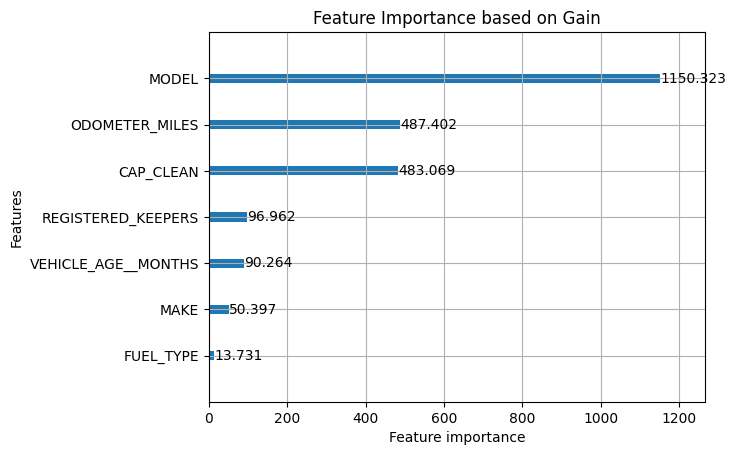

In [13]:
lgb.plot_importance(lgbrefurb_search.fit(X_train, y_train), importance_type='gain')
plt.title("Feature Importance based on Gain")
plt.show()

# Inference

In [14]:
inference = pd.read_csv('../data/inference.csv')

In [15]:
inference

,V_NO,MAKE,MODEL,COLOUR,FUEL_TYPE,REGISTERED_KEEPERS,CAPCLEAN,ODOMETER_MILES,VEHICLE_AGE__MONTHS,REGISTRATION_DATE,VEHICLE_SOURCE,TRANSMISSION_TYPE
0,35875,MERCEDES-BENZ,GLC,BLUE,Diesel,3.0,15500.0,76519.0,96.0,20/05/2019,TradeZone,MANUAL
1,3072,VOLVO,V40,BLACK,Diesel,2.0,2100.0,150179.0,125.0,28/06/2016,TradeZone,MANUAL
2,62934,VAUXHALL,GRANDLAND X,RED,Petrol,2.0,9475.0,65258.0,53.0,09/05/2019,TradeZone,MANUAL
3,98631,SMART,FORTWO COUPE,BLACK,Petrol,2.0,5575.0,56186.0,94.0,11/09/2017,TradeZone,SEMI-AUTO
4,10724,VOLVO,XC60,BLUE,Diesel,3.0,4425.0,210000.0,96.0,08/06/2020,TradeZone,MANUAL
...,...,...,...,...,...,...,...,...,...,...,...,...
5596,20916,DS,DS 3 CROSSBACK,BLACK,Petrol,1.0,13150.0,18239.0,36.0,28/09/2018,TradeZone,MANUAL
5597,93678,DS,DS 3 CROSSBACK,WHITE,Petrol,1.0,13800.0,12034.0,30.0,16/09/2020,OTHER,AUTO
5598,64499,SKODA,FABIA,BLACK,Petrol,4.0,7600.0,52674.0,73.0,30/11/2021,TradeZone,AUTO
5599,7540,SKODA,FABIA,GREY,Petrol,4.0,8800.0,32297.0,68.0,21/12/2022,TradeZone,SEMI-AUTO


In [16]:
inference.columns

Index(['V_NO', 'MAKE', 'MODEL', 'COLOUR', 'FUEL_TYPE', 'REGISTERED_KEEPERS',
       'CAPCLEAN', 'ODOMETER_MILES', 'VEHICLE_AGE__MONTHS',
       'REGISTRATION_DATE', 'VEHICLE_SOURCE', 'TRANSMISSION_TYPE'],
      dtype='object')

In [17]:
pred_columns = ['MAKE', 'MODEL', 'FUEL_TYPE',
       'REGISTERED_KEEPERS', 'CAPCLEAN', 'ODOMETER_MILES',
       'VEHICLE_AGE__MONTHS']

In [18]:
inference.MAKE = inference.MAKE.astype("category")
inference.MODEL = inference.MODEL.astype("category")
inference.FUEL_TYPE = inference.FUEL_TYPE.astype("category")
y_pred_, intervals = lgbrefurb_mapie.predict(inference[pred_columns])
y_pi_lower_ = intervals[:, 0] 
y_pi_upper_ = intervals[:, 1]

[LightGBM] [Warning] min_data_in_leaf is set=15, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=15
[LightGBM] [Warning] feature_fraction is set=0.3437275158793811, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.3437275158793811
[LightGBM] [Warning] bagging_fraction is set=0.9377259931441667, subsample=0.7677071379588588 will be ignored. Current value: bagging_fraction=0.9377259931441667
[LightGBM] [Warning] bagging_freq is set=6, subsample_freq=0 will be ignored. Current value: bagging_freq=6
[LightGBM] [Warning] min_data_in_leaf is set=15, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=15
[LightGBM] [Warning] feature_fraction is set=0.3437275158793811, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.3437275158793811
[LightGBM] [Warning] bagging_fraction is set=0.9377259931441667, subsample=0.7677071379588588 will be ignored. Current value: bagging_fraction=0.9377259931441667
[LightGBM] [Warn

In [ ]:
# Flatten the arrays to 1-dimensional
y_pred_ = y_pred_.ravel()
y_pi_lower_ = y_pi_lower_.ravel()
y_pi_upper_ = y_pi_upper_.ravel()

# Combine predictions and intervals into a DataFrame
predictions_df = pd.DataFrame({
    "refurb_cost_predictions": np.round(y_pred_,2),
    "refurb_cost_predictions_lower": np.round(y_pi_lower_,2),
    "refurb_cost_predictions_upper": np.round(y_pi_upper_,2)
})

# Concatenate with VRM and VEHICLE_ID columns
result_df = pd.concat([inference["V_NO"].reset_index(drop=True), predictions_df], axis=1)

# Display the resulting DataFrame
print(result_df)

       V_NO  refurb_cost_predictions  refurb_cost_predictions_lower  \
0     35875                   582.31                         301.85   
1      3072                   579.29                         295.99   
2     62934                   556.44                         305.57   
3     98631                   578.67                         302.10   
4     10724                   568.44                         300.93   
...     ...                      ...                            ...   
5596  20916                   546.15                         297.83   
5597  93678                   545.62                         299.88   
5598  64499                   595.49                         303.91   
5599   7540                   595.49                         301.04   
5600  80784                   581.05                         304.09   

      refurb_cost_predictions_upper  
0                           1119.09  
1                           1020.10  
2                           1060.